In [1]:
import numpy as np
import dpluspy 
import matplotlib.pyplot as plt 
import matplotlib 
import scipy
import demes 
import demesdraw
from bokeh.palettes import Category20
import pandas
from matplotlib.transforms import ScaledTranslation

In [2]:
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}\usepackage{amssymb}"
matplotlib.rcParams['font.family'] = "serif"
matplotlib.rcParams['font.serif'] = "Computer Modern"
matplotlib.rcParams['savefig.bbox'] = "tight"
matplotlib.rcParams['axes.linewidth'] = 0.5
lw = 0.8

In [3]:
graph0 = "../models/ghost_introgression/main/fitted_models/null_Bherer_fit_16.yaml"
graph1 = "../models/ghost_introgression/main/fitted_models/fixed_2Ma_Bherer_fit_2.yaml"

data = dpluspy.inference.load_stats(
    "../models/data/stats_Bherer_weighted.pkl", graph=graph1, return_dict=1)
bins = data["bins"]
pop_ids = data["pop_ids"]
model0 = dpluspy.inference.compute_bin_stats(graph0, bins=bins, u=1.3e-8, 
    sampled_demes=pop_ids)
model1 = dpluspy.inference.compute_bin_stats(graph1, bins=bins, u=1.3e-8, 
    sampled_demes=pop_ids)

tbl0b = pandas.read_csv(
    "../models/ghost_introgression/bootstrap_full/null_Bherer.csv")
tbl1b = pandas.read_csv(
    "../models/ghost_introgression/bootstrap_full/TS_fixed_2Ma_Bherer.csv")
d_lrt_bher = 2 * (np.array(tbl1b["ll"]) - np.array(tbl0b["ll"]))

tbl0z = pandas.read_csv(
    "../models/ghost_introgression/bootstrap_full/null_ZhouJHS.csv")
tbl1z = pandas.read_csv(
    "../models/ghost_introgression/bootstrap_full/TS_fixed_2Ma_ZhouJHS.csv")
d_lrt_zhou = 2 * (np.array(tbl1z["ll"]) - np.array(tbl0z["ll"]))

In [4]:
positions = {
    "Yoruba1": 6e4,
    "Stuttgart": 9e4,
    "Loschbour": 6e4,
    "UstIshim": 3e4,
    "Vindija": 1.2e5,
    "Chagyrskaya": 1.5e5, 
    "Altai": 1.8e5,
    "Denisova": 2.1e5,
    "Sup": 2.4e5,
    "MH": 3e4, 
    "WN": 1.35e5,
    "N": 1.55e5,
    "ND": 1.81e5,
    "Anc": 1.15e5
}
cs = Category20[20]
colors = {
    "Yoruba1": cs[0],
    "UstIshim": cs[2],
    "Loschbour": cs[4],
    "Stuttgart": cs[6],
    "Vindija": cs[8],
    "Chagyrskaya": cs[10],
    "Altai": cs[12],
    "Denisova": cs[14],
    "Sup": cs[1],
    "MH": cs[3],
    "WN": cs[5],
    "N": cs[7],
    "ND": cs[9],
    "Anc": cs[11],
}

In [5]:
def plot_graph(ax):
    fname = "../models/ghost_introgression/main/edited_models/fixed_2Ma_Bherer_fit_2_edited.yaml"
    graph = demes.load(fname)
    pops = [
        "Anc",
        "Sup",
        "Yoruba1",
        "WN",
        "N", 
        "ND",
        "Vindija",
        "Chagyrskaya",
        "Altai",
        "Denisova"
    ]
    demesdraw.tubes(
        graph,
        ax=ax,
        labels=None,
        log_time=True,
        inf_ratio=0.02,
        positions={x: positions[x] for x in pops},
        colours={x: colors[x] for x in pops},
        num_lines_per_migration=4,
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)
    
    # annotate demes
    ax.annotate("Vindija", (positions["Vindija"] - 1.5e4, 3.9e4), fontsize="x-small")
    ax.annotate("Chagyrskaya", (positions["Chagyrskaya"] - 2.3e4, 4.85e4), fontsize="x-small")
    ax.annotate("Altai", (positions["Altai"] - 1e4, 9.7e4), fontsize="x-small")
    ax.annotate("Denisova", (positions["Denisova"] - 1.7e4, 5.3e4), fontsize="x-small")
    ax.set_xticks([positions["Yoruba1"]], ["Yoruba"], fontsize="x-small")
    ax.annotate("[Sup.]", (positions["Sup"] - 1e4, 6.5e5), fontsize="x-small")

    ax.set_yticks([5e4, 1e5, 5e5, 1e6, 2e6], 
                  ["$50$", "$100$", "$500$", "$1000$", "$2000$"])
    ax.set_ylim(3e4,)
    ax.set_ylabel("Time (ka)")
    return

In [6]:
def plot_lrt_distr(ax):
    lw = 1
    thresh = scipy.stats.chi2.ppf(0.95, 1)
    bins = np.concat([[0, thresh], np.linspace(thresh, 150, 40)[1:]])
    ax.step(np.append(bins, bins[-1]), 
            np.concat(([0], (np.histogram(d_lrt_bher, bins=bins)[0] / len(d_lrt_bher)), [0])),
            lw=lw, color="blue", label="Bhérer")
    ax.step(np.append(bins, bins[-1]), 
            np.concat(([0], (np.histogram(d_lrt_zhou, bins=bins)[0] / len(d_lrt_zhou)), [0])),
            lw=lw, color="red", label="Zhou JHS")
    ax.set_xlabel("LRT statistic")
    ax.set_ylabel("Frequency")
    ax.set_ylim(0, )
    ax.legend(framealpha=0, title=r"$H_0: \varnothing, H_1: \alpha$", 
              title_fontsize="small")
    ax.vlines(thresh, 0, 1, color="black", lw=0.7, linestyle="--",
        transform=ax.get_xaxis_transform())
    return

In [7]:
lw = 1

def plot_panel_c(ax):
    dpluspy.plotting.plot_data_on_ax(ax, data, "D+_3_3", "data", 
        color="grey", linestyle="--", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model0, bins, "D+_3_3",
        "null", color="tab:blue", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model1, bins, "D+_3_3",
        r"S$\to$D", color="tab:orange", lw=lw)
    ax.set_title("$D^+$(Vin)", )
    ax.legend(framealpha=0)
    return


def plot_panel_d(ax):
    dpluspy.plotting.plot_data_on_ax(ax, data, "D+_3_4", "data", 
        color="grey", linestyle="--", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model0, bins, "D+_3_4",
        "null", color="tab:blue", lw=lw)
    dpluspy.plotting.plot_model_on_ax(ax, model1, bins, "D+_3_4",
        r"S$\to$D", color="tab:orange", lw=lw)
    ax.set_title("$D^+$(Den,Yor)", )
    ax.legend(framealpha=0)
    return

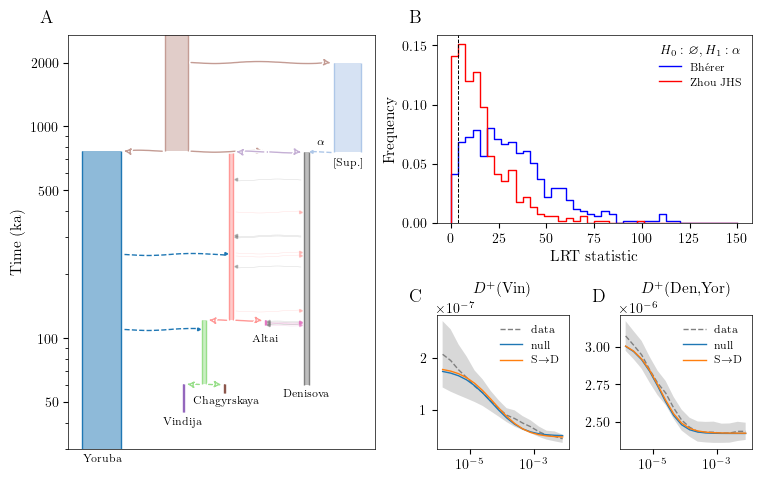

In [8]:
mosaic = "AABB;AACD"
fig, axs = plt.subplot_mosaic(mosaic, figsize=(7.5, 4.7), layout="constrained",
                              height_ratios=[1.4, 1])
for label, ax in axs.items():
    ax.text(0.0, 1.0, label, fontsize="large", va="bottom", transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)))

plot_graph(axs["A"])
axs["A"].annotate(r"$\alpha$", [2.18e5, 8.2e5], size="x-small")
plot_lrt_distr(axs["B"])
plot_panel_c(axs["C"])
plot_panel_d(axs["D"])

plt.savefig("figures/fig4.pdf")

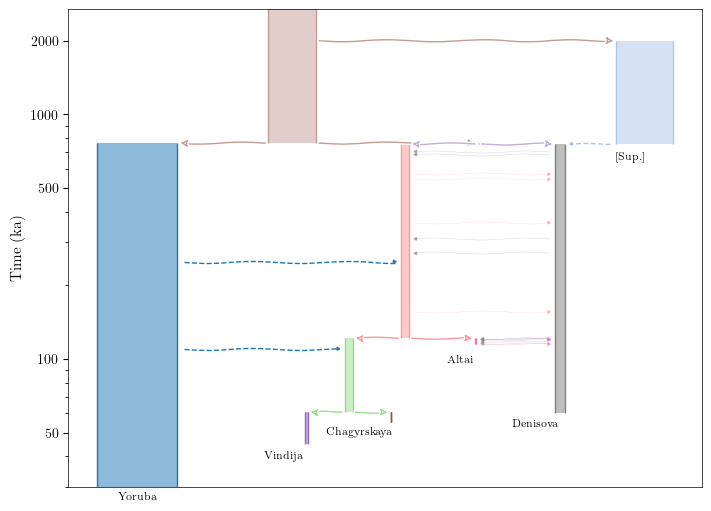

In [9]:
def _plot_graph(ax):
    fname = graph1
    graph = demes.load(fname)
    positions = {
        "Yoruba1": 0,
        "Vindija": 6e4,
        "Chagyrskaya": 1e5, 
        "Altai": 1.4e5,
        "Denisova": 1.8e5,
        "WN": 8e4,
        "N": 1.1e5,
        "ND": 1.45e5,
        "Anc": 7e4,
        "Sup": 2.2e5
    }
    samples = [
        "Yoruba1", 
        "Vindija", 
        "Chagyrskaya", 
        "Altai", 
        "Denisova"
    ]
    labels = [
        "Yoruba", 
        "Vindija", 
        "Chagyrskaya", 
        "Altai", 
        "Denisova"
    ]
    demesdraw.tubes(
        graph,
        ax=ax,
        labels=None,
        log_time=True,
        inf_ratio=0.035,
        positions=positions,
        num_lines_per_migration=4
    )
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.spines["bottom"].set_visible(True)

    # annotations
    ax.annotate("Vindija", (positions["Vindija"] - 1e4, 3.7e4))
    ax.annotate("Chagyrskaya", (positions["Chagyrskaya"] - 1.3e4, 4.6e4))
    ax.annotate("Altai", (positions["Altai"] - 6e3, 9.3e4))
    ax.annotate("Denisova", (positions["Denisova"] - 1e4, 5e4))
    ax.set_xticks([positions["Yoruba1"]], ["Yoruba"])

    ax.set_ylim(3e4,)
    # ax.set_xlim(-4e4, 3e5)
    ax.set_ylabel("Time (years)")
    return

fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
plot_graph(ax)
#inset = ax.inset_axes([0.60, 0.10, 0.37, 0.25])
#plot_lrt_distr(inset)
plt.savefig("extra_figures/sd_model.png", dpi=244)

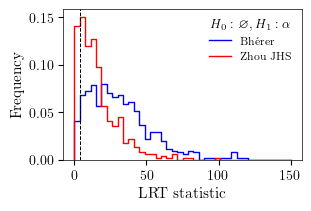

In [10]:
def _plot_lrt_distr(ax):
    thresh = scipy.stats.chi2.ppf(0.95, 1)
    bins = np.concat([[0, thresh], np.linspace(thresh, 150, 50)[1:]])
    ax.hist(d_lrt_bher, histtype="step", bins=bins, lw=lw, color="blue")
    ax.set_xlabel("LRT statistic")
    ax.set_ylabel("Count (of 510)")
    ax.vlines(thresh, 0, 1, color="black", lw=1, linestyle="--",
        transform=ax.get_xaxis_transform())
    return


fig, ax = plt.subplots(figsize=(3, 2), layout="constrained")
plot_lrt_distr(ax)
plt.savefig("extra_figures/sd_bootstrap.png", dpi=244)